In [35]:
import re
import time
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import math

# Part 1 ‐ Exploratory data analysis
### The attached logins.json file contains (simulated) timestamps of user logins in a particular geographic location. Aggregate these login counts based on 15minute time intervals, and visualize and describe the resulting time series of login counts in ways that best characterize the underlying patterns of the demand. Please report/illustrate important features of the demand, such as daily cycles. If there are data quality issues, please report them

In [51]:
df = pd.read_json('logins.json')

df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB


In [53]:
df_indexed = df.set_index('login_time')

df_indexed['count'] = 1

df_15min = df_indexed.resample('15min').sum()

df_15min.head(10)

,count
login_time,
1970-01-01 20:00:00,2
1970-01-01 20:15:00,6
1970-01-01 20:30:00,9
1970-01-01 20:45:00,7
1970-01-01 21:00:00,1
1970-01-01 21:15:00,4
1970-01-01 21:30:00,0
1970-01-01 21:45:00,4
1970-01-01 22:00:00,9


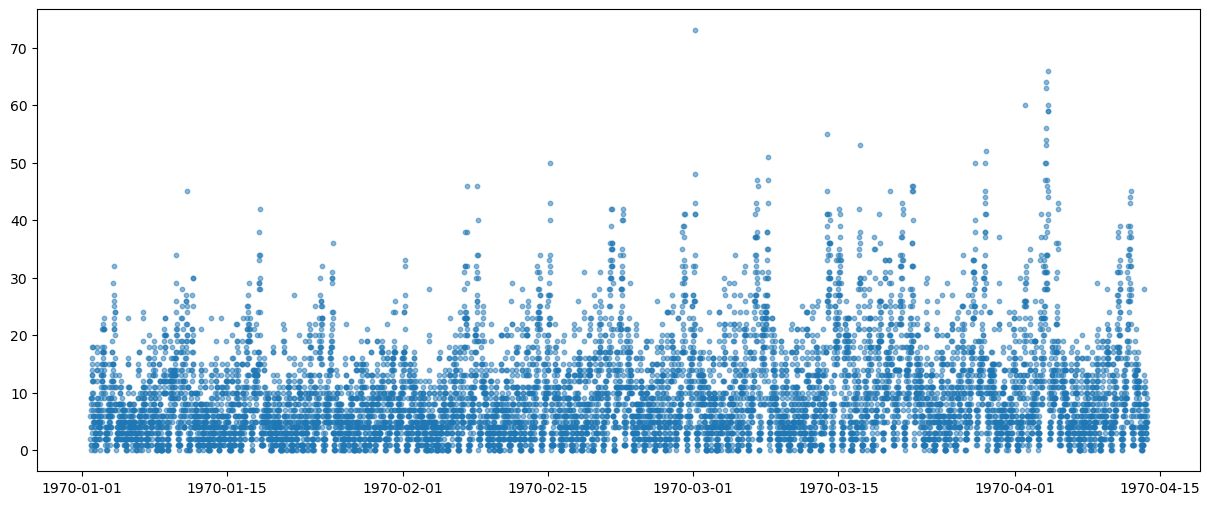

In [54]:
#Scatter plot of 15 min sampled logins
plt.figure(figsize=(15, 6))
plt.scatter(df_15min.index, df_15min['count'], alpha=0.5, s=10)
plt.show()

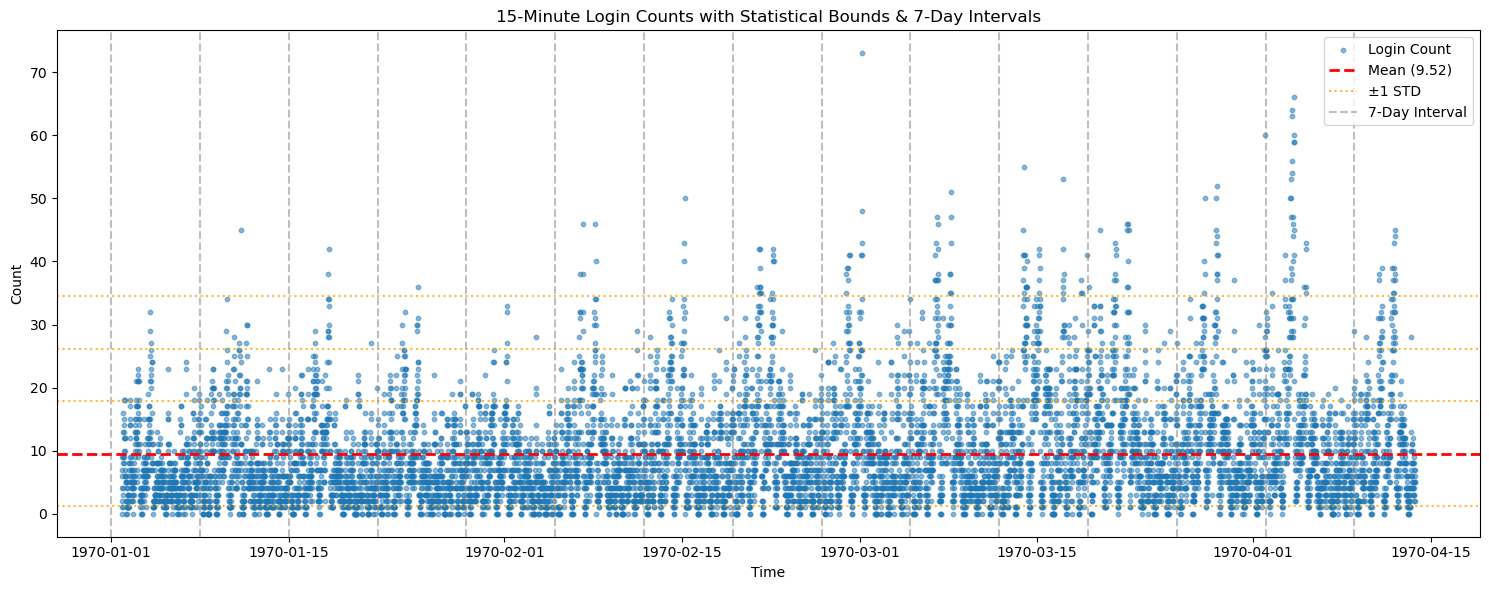

In [55]:
# Plotting an improved 15-min scatter plot
# Calculate summary statistics
mean_val = df_15min['count'].mean()
std_val = df_15min['count'].std()

plt.figure(figsize=(15, 6))

# 1. Scatter plot of 15-min login counts
plt.scatter(df_15min.index, df_15min['count'], alpha=0.5, s=10, label='Login Count', color='tab:blue')

# 2. Horizontal line for the Mean
plt.axhline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.2f})')

# 3. Horizontal lines for 1, 2, and 3 Standard Deviations
for i in range(1, 4):
    upper = mean_val + i * std_val
    lower = max(0, mean_val - i * std_val)  # Floor lower bound at 0 if counts can't be negative
    
    # Label only the first pass for a clean legend
    plt.axhline(upper, color='orange', linestyle=':', alpha=0.8, label=f'±{i} STD' if i == 1 else "")
    if lower > 0:
        plt.axhline(lower, color='orange', linestyle=':', alpha=0.8)

# 4. Vertical lines every 7 days starting from 1970-01-01
start_date = pd.Timestamp('1970-01-01')
end_date = df_15min.index.max()
weekly_dates = pd.date_range(start=start_date, end=end_date, freq='7D')

for idx, dt in enumerate(weekly_dates):
    plt.axvline(dt, color='gray', linestyle='--', alpha=0.5, label='7-Day Interval' if idx == 0 else "")

# Formatting
plt.title('15-Minute Login Counts with Statistical Bounds & 7-Day Intervals')
plt.xlabel('Time')
plt.ylabel('Count')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

In [56]:
# Add time components to the aggregated DataFrame
df_15min['hour'] = df_15min.index.hour
df_15min['day_of_week'] = df_15min.index.day_name()
df_15min['is_weekend'] = df_15min.index.weekday >= 5

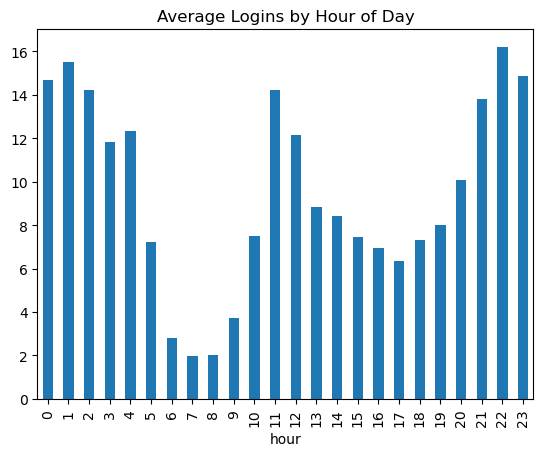

In [57]:
# Average logins by hour of day (Daily pattern)
df_15min.groupby('hour')['count'].mean().plot(kind='bar', title='Average Logins by Hour of Day')
plt.show()

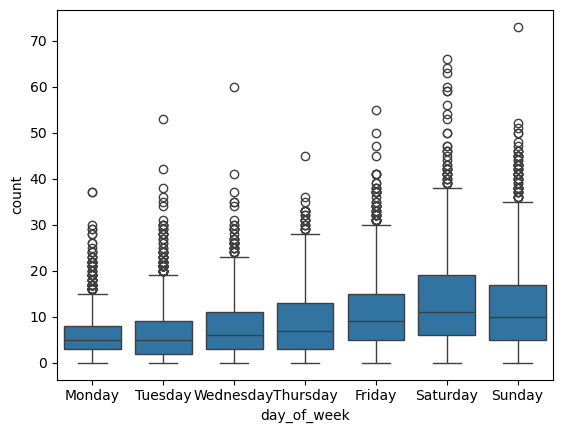

In [58]:
# Distribution of logins across days of the week
sns.boxplot(data=df_15min, x='day_of_week', y='count',
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()

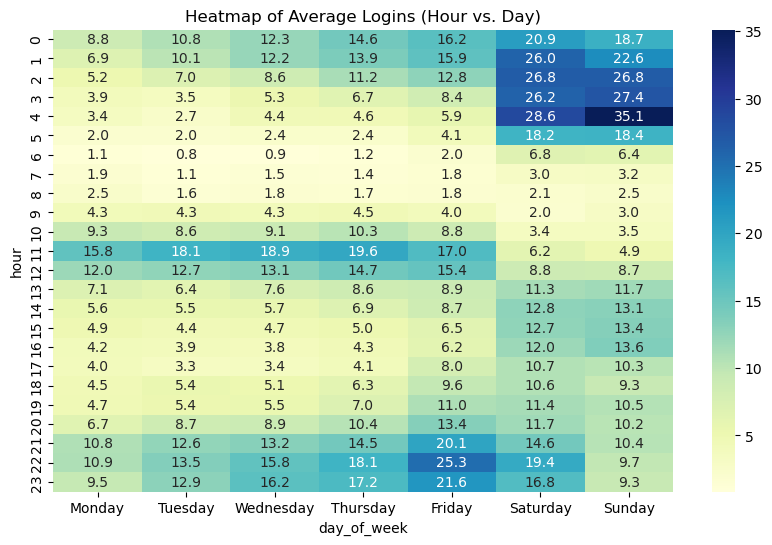

In [59]:
pivot = df_15min.pivot_table(index='hour', columns='day_of_week', values='count', aggfunc='mean')
# Reorder columns to standard calendar order
pivot = pivot[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.1f')
plt.title('Heatmap of Average Logins (Hour vs. Day)')
plt.show()

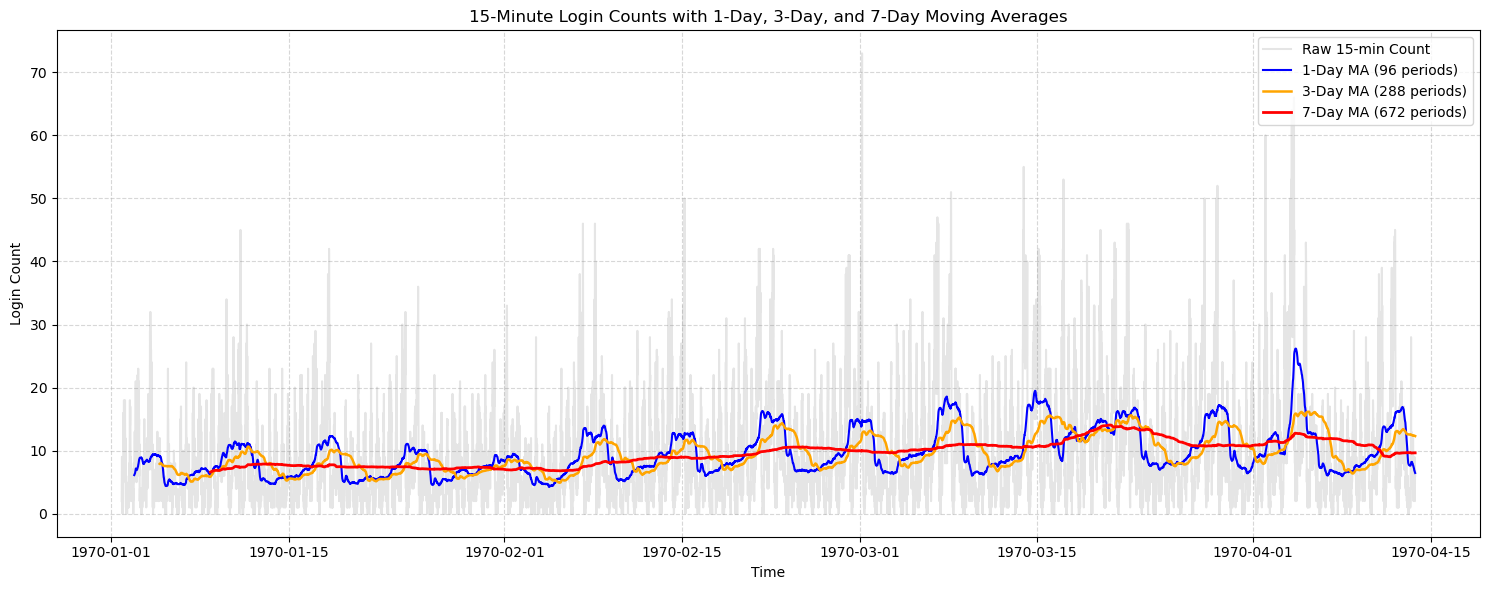

In [60]:
# Calculate daily rolling averages (96 fifteen-minute periods per day)
df_15min['ma_1d'] = df_15min['count'].rolling(window=96).mean() #1 day
df_15min['ma_3d'] = df_15min['count'].rolling(window=288).mean() #3 days
df_15min['ma_7d'] = df_15min['count'].rolling(window=672).mean() #7 days

# Plot original data and daily rolling averages
plt.figure(figsize=(15, 6))

# Plot raw counts with transparency
plt.plot(df_15min.index, df_15min['count'], alpha=0.2, color='gray', label='Raw 15-min Count')

# Plot moving averages
plt.plot(df_15min.index, df_15min['ma_1d'], color='blue', linewidth=1.5, label='1-Day MA (96 periods)')
plt.plot(df_15min.index, df_15min['ma_3d'], color='orange', linewidth=1.8, label='3-Day MA (288 periods)')
plt.plot(df_15min.index, df_15min['ma_7d'], color='red', linewidth=2.0, label='7-Day MA (672 periods)')

plt.title('15-Minute Login Counts with 1-Day, 3-Day, and 7-Day Moving Averages')
plt.xlabel('Time')
plt.ylabel('Login Count')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Part 1 Summary
### <b>Data issue:</b> The dates begin from 1/1/1970 instead of a more modern era
### <b>Patterns:</b> There is a clear weekly cycle as evidence by the 1-day and 3-day moving averages. The 7-day allows me to see that the the overall count of logins is increasing over time.
### <b>Insights:</b> Saturday is the highest volume day of the week. 
### Most logins happen early morning Saturday and Sunday
### Fewest logins happen 7-9am on weekdays

# Part 2 ‐ Experiment and metrics design
### The neighboring cities of Gotham and Metropolis have complementary circadian rhythms: on weekdays, Ultimate Gotham is most active at night, and Ultimate Metropolis is most active during the day. On weekends, there is reasonable activity in both cities. However, a toll bridge, with a two way toll, between the two cities causes driver partners to tend to be exclusive to each city. The Ultimate managers of city operations for the two cities have proposed an experiment to encourage driver partners to be available in both cities, by reimbursing all toll costs.
### 1) What would you choose as the key measure of success of this experiment in encouraging driver partners to serve both cities, and why would you choose this metric?
### 2) Describe a practical experiment you would design to compare the effectiveness of the proposed change in relation to the key measure of success. Please provide details on: a) how you will implement the experiment b) what statistical test(s) you will conduct to verify the significance of the observation c) how you would interpret the results and provide recommendations to the city operations team along with any caveats.
### Note: The two cities of Gotham and Metropolis are not in the provided dataset; however, you do not need this information to answer Part 2.

### 1) 
My metric would be ratio of cross-bridge trips to total trips. This could be further broken down by driver partner. This metric directly addresses the goal of having drivers serve both cities. A secondary metric would be the profit generated. This reimbursement is going to add cost to Ultimate's operations so they will want to ensure that it is adding profit or at least not cuasing large losses. 

#### 2)
a) The experiment would be to randomly assign drivers to Test and Control groups. Drivers should be randomly assigned such that there is a reprsentative sample for each feature: city, time of day, etc. For Control, nothing changes. For Test, they are notified they will now be reimbursed for all cross-bridge trips.
<br> b) I would conduct a two-sample t-test. The null hypothesis is: There is no difference in the mean ratio of cross-bridge trips between Test and Control. I may use a default significance threshold of 0.05 or adjust based on what is practical for the business. 
<br> c) If the p-value is less 0.05, I will reject the null hypothesis and conclude that there is a statistically significant difference between Test and Control. As mentioned in my answer to #1, I would also recommend the business verify incremental profit with this change. If so, I would recommend a broader rollout and more analysis. Some possible concerns with this experiment would be that drivers become unhappy they were not selected for the Test group or that wait times increase for passengers. Again, these are secondary metrics the business should monitor closely.  

# Part 3 ‐ Predictive modeling
Ultimate is interested in predicting rider retention. To help explore this question, we have
provided a sample dataset of a cohort of users who signed up for an Ultimate account in
January 2014. The data was pulled several months later; we consider a user retained if they
were “active” (i.e. took a trip) in the preceding 30 days.
We would like you to use this data set to help understand what factors are the best predictors
for retention, and offer suggestions to operationalize those insights to help Ultimate.
The data is in the attached file ultimate_data_challenge.json. See below for a detailed
description of the dataset. Please include any code you wrote for the analysis and delete the
dataset when you have finished with the challenge.
1. Perform any cleaning, exploratory analysis, and/or visualizations to use the provided
data for this analysis (a few sentences/plots describing your approach will suffice). What
fraction of the observed users were retained?
2. Build a predictive model to help Ultimate determine whether or not a user will be active in
their 6th month on the system. Discuss why you chose your approach, what alternatives
you considered, and any concerns you have. How valid is your model? Include any key
indicators of model performance.
3. Briefly discuss how Ultimate might leverage the insights gained from the model to
improve its long term rider retention (again, a few sentences will suffice).

In [61]:
df2 = pd.read_json('ultimate_data_challenge.json')

df2.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [62]:
# Note that there are some nulls for avg_rating_of_driver, phone, and avg_rating_by_driver
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


In [63]:
# Convert date columns to datetime objects
df2["signup_date"] = pd.to_datetime(df2["signup_date"])
df2["last_trip_date"] = pd.to_datetime(df2["last_trip_date"])

df2.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


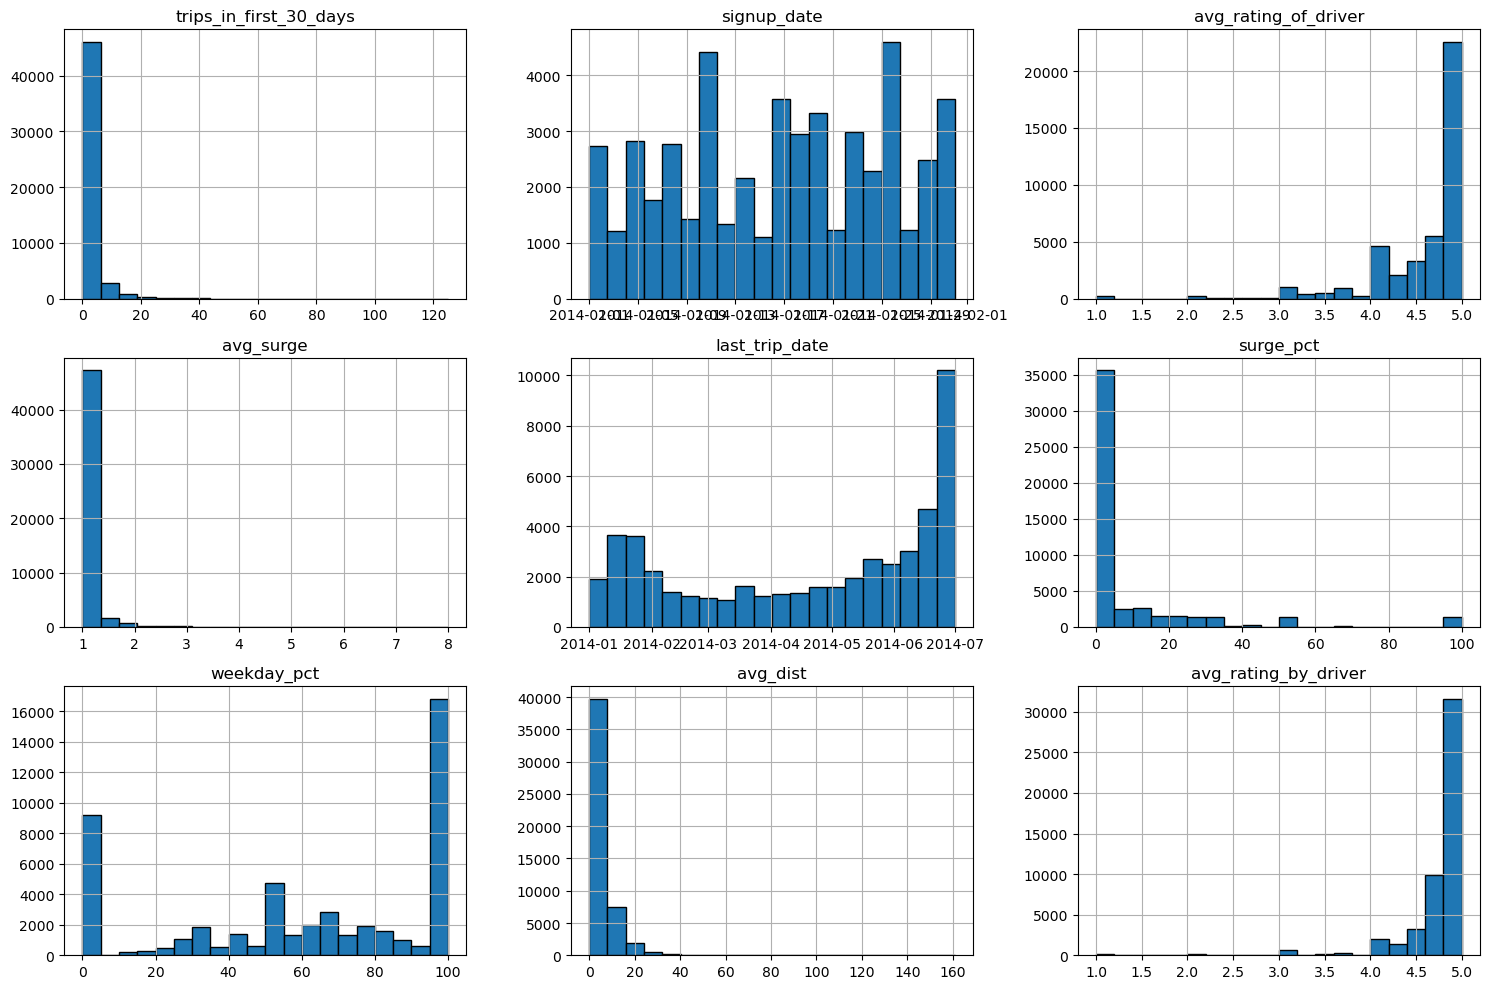

In [64]:
# Plot histograms for all numerical features in df2 (3 charts per row)
df2.hist(figsize=(15, 10), layout=(-1, 3), bins=20, edgecolor="black")

# Adjust layout so title/labels don't overlap
plt.tight_layout()
plt.show()

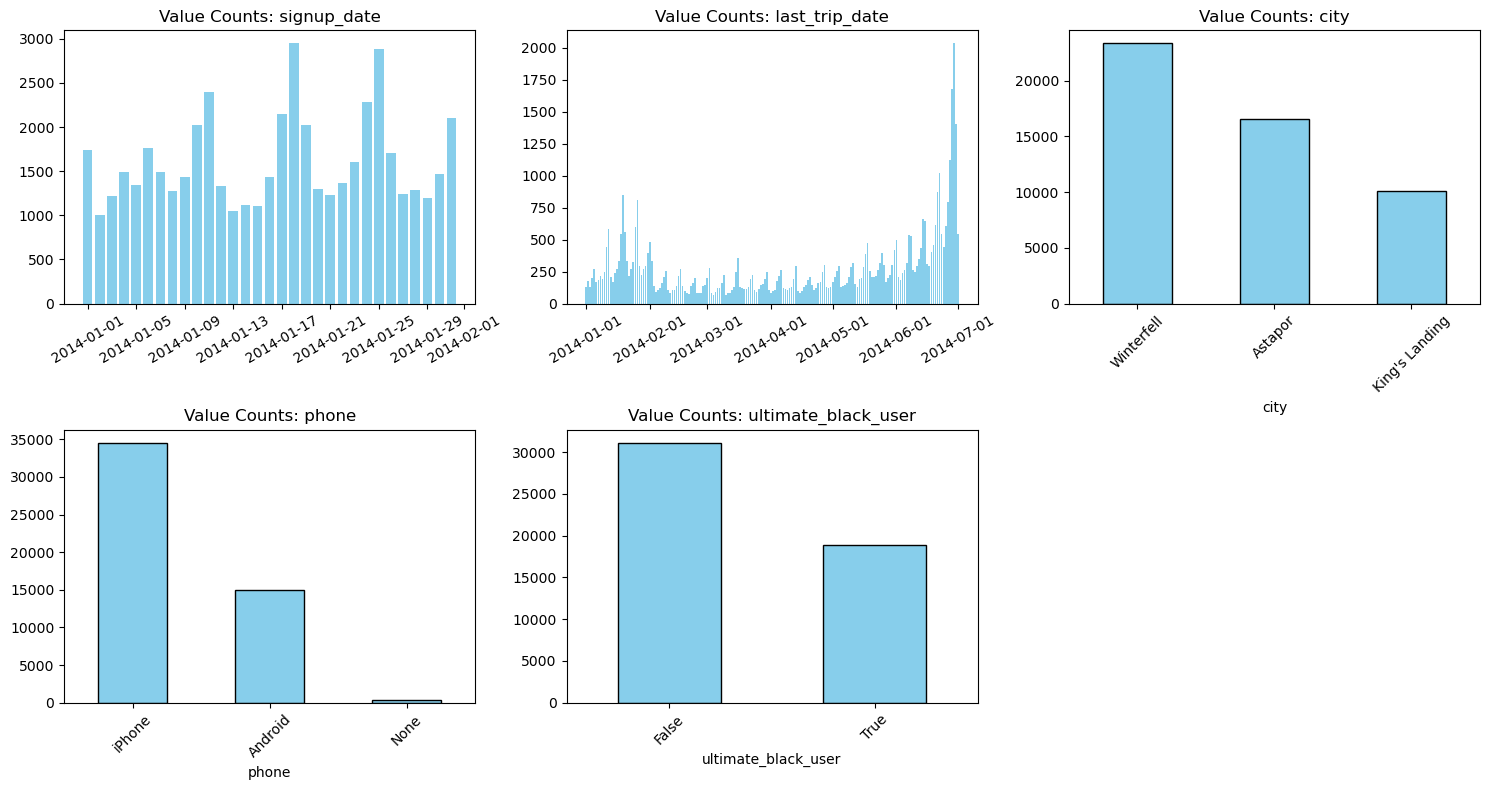

In [65]:
# Define the non-numeric/date columns to plot
date_cols = ["signup_date", "last_trip_date"]
cat_cols = list(df2.select_dtypes(include=["object", "category", "bool"]).columns)
all_target_cols = date_cols + cat_cols

# Setup subplots grid (3 per row)
n_cols = 3
n_rows = (len(all_target_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(all_target_cols):
    ax = axes[i]

    if col in date_cols:
        # Aggregate counts by sorted date
        counts = df2[col].value_counts(dropna=False).sort_index()

        ax.bar(counts.index, counts.values, color="skyblue", width=0.8)
        ax.set_title(f"Value Counts: {col}")

        # Auto-space and format date ticks cleanly
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.tick_params(axis="x", rotation=30)
    else:
        # Standard categorical bar plot
        df2[col].value_counts(dropna=False).plot(
            kind="bar", ax=ax, color="skyblue", edgecolor="black"
        )
        ax.set_title(f"Value Counts: {col}")
        ax.tick_params(axis="x", rotation=45)

# Hide any unused subplot axes in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Retained Users

In [66]:
# 1. Determine the latest trip date in the dataset (assumed data pull date)
max_date = df2["last_trip_date"].max()
max_date

Timestamp('2014-07-01 00:00:00')

In [67]:
# 2. Define the retention threshold (30 days prior to max date)
cutoff_date = max_date - pd.Timedelta(days=30)

# 3. Create a boolean column for retained users (active in the last 30 days)
df2["retained"] = df2["last_trip_date"] >= cutoff_date
df2["retained"].head(10)

0     True
1    False
2    False
3     True
4    False
5     True
6    False
7    False
8    False
9    False
Name: retained, dtype: bool

In [68]:
# 4. Filter for active/retained users dataframe
active_users = df2[df2["retained"]]

# Display results summary
retained_count = df2["retained"].sum()
retention_rate = df2["retained"].mean() * 100

print(f"Max trip date (data pull date): {max_date.strftime('%Y-%m-%d')}")
print(f"Cutoff date for retention:     {cutoff_date.strftime('%Y-%m-%d')}\n")
print(f"Total Retained Users: {retained_count:,} out of {len(df2):,}")
print(f"Retention Rate:       {retention_rate:.2f}%")

# Preview the active users dataframe
active_users.head()

Max trip date (data pull date): 2014-07-01
Cutoff date for retention:     2014-06-01

Total Retained Users: 18,804 out of 50,000
Retention Rate:       37.61%


,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,retained
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0,True
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9,True
5,Winterfell,2,2014-01-09,3.5,1.00,2014-06-06,iPhone,0.0,True,100.0,10.56,5.0,True
13,King's Landing,0,2014-01-29,4.0,1.38,2014-06-08,iPhone,50.0,False,50.0,3.04,5.0,True
16,King's Landing,1,2014-01-11,5.0,1.00,2014-06-28,Android,0.0,True,50.0,10.86,3.0,True


In [79]:
# Non-retained averages
df2[df2['retained']==False].mean(numeric_only=True)

trips_in_first_30_days     1.658482
avg_rating_of_driver       4.607557
avg_surge                  1.075339
surge_pct                  8.666739
ultimate_black_user        0.299942
weekday_pct               60.647032
avg_dist                   6.207939
avg_rating_by_driver       4.787464
retained                   0.000000
dtype: float64

In [78]:
# Retained averages
df2[df2['retained']==True].mean(numeric_only=True)

trips_in_first_30_days     3.306318
avg_rating_of_driver       4.592930
avg_surge                  1.073809
surge_pct                  9.152797
ultimate_black_user        0.505052
weekday_pct               61.389034
avg_dist                   5.114788
avg_rating_by_driver       4.762772
retained                   1.000000
dtype: float64

# Predictive model
### Clean up the data

In [20]:
# Convert boolean columns to integer (1 / 0)
df2['ultimate_black_user'] = df2['ultimate_black_user'].astype(int)
df2['retained'] = df2['retained'].astype(int)

In [21]:
# Impute numeric missing values with means
df2['avg_rating_of_driver'] = df2['avg_rating_of_driver'].fillna(df2['avg_rating_of_driver'].mean())
df2['avg_rating_by_driver'] = df2['avg_rating_by_driver'].fillna(df2['avg_rating_by_driver'].mean())

# Impute categorical missing values in phone with the mode ('iPhone')
df2['phone'] = df2['phone'].fillna(df2['phone'].mode()[0])

In [22]:
# One-hot encode categorical features ('city' and 'phone')
df2 = pd.get_dummies(df2, columns=['city', 'phone'], drop_first=True, dtype=int)

In [23]:
# Drop signup_date and last_trip_date (data leakage / timestamp features)
df2 = df2.drop(columns=['signup_date', 'last_trip_date'])

In [24]:
df2.head()

,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,retained,city_King's Landing,city_Winterfell,phone_iPhone
0,4,4.7,1.10,15.4,1,46.2,3.67,5.0,1,1,0,1
1,0,5.0,1.00,0.0,0,50.0,8.26,5.0,0,0,0,0
2,3,4.3,1.00,0.0,0,100.0,0.77,5.0,0,0,0,1
3,9,4.6,1.14,20.0,1,80.0,2.36,4.9,1,1,0,1
4,14,4.4,1.19,11.8,0,82.4,3.13,4.9,0,0,1,0


### Train the model

In [25]:
from sklearn.model_selection import train_test_split

X = df2.drop(columns=["retained"])# features
y = df2["retained"].astype(int)  # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

### Model results

In [27]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      6239
           1       0.69      0.66      0.67      3761

    accuracy                           0.76     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.76      0.76      0.76     10000

ROC-AUC Score: 0.8267


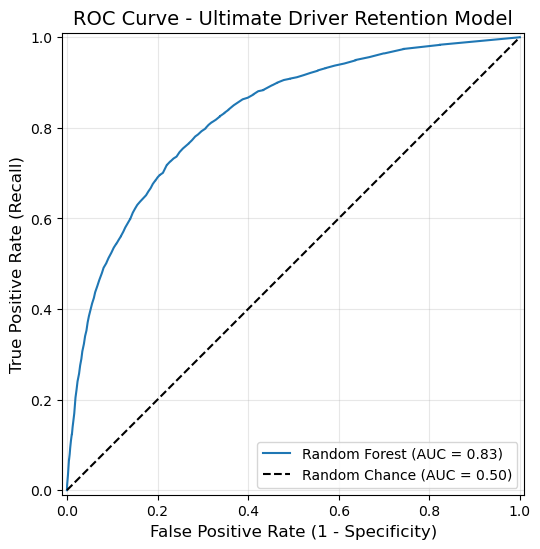

In [28]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Plot ROC curve using model predictions on the test set
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name='Random Forest')

# Add baseline reference line (random chance = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')

plt.title('ROC Curve - Ultimate Driver Retention Model', fontsize=14)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

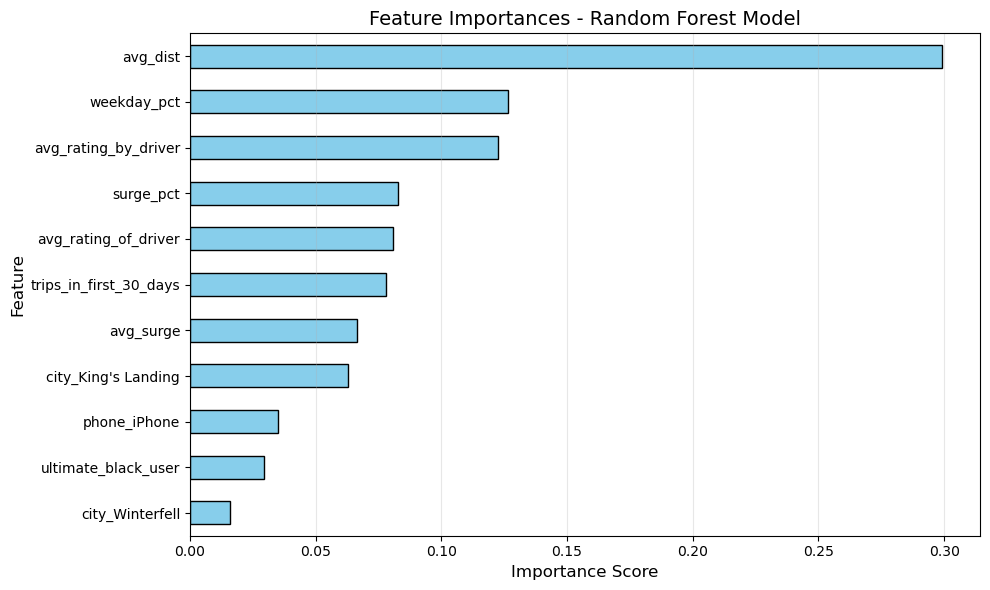

In [80]:
# Extract feature importances and pair them with column names
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('Feature Importances - Random Forest Model', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Summary

18,804 out of 50,000 users were retained (37.61%)

I chose a Random Forest model because it handles mixed data types well and captures non-linear relationships well.

The Random Forest model performs well with ROC-AUC score of 0.83. This means it has an 83% probability of correctly ranking a retained user above a churned user.

Based on the feature importance - average distance is the largest driver. I attribute this to users utilizing Ultimate for work or airport trips. Ultimate could introduce commuter passes or flat-rate rides to keep these users coming back. 

The percent of the user’s trips occurring during a weekday was the second most important. I believe users that ride during the week have incorporated Ultimate into a regular part of their routine, whereas riding on weekends might be sporadic. Ultimate could entice these users with a subscription discount or daily commute discount. 

Average Rating by Driver and Average Rating of Driver indicate that mutual satisfaction for drivers and passengers is important. I believe this satisfaction may come from good communication, on time arrival, and respect for one another. Ultimate could remind riders/drivers of etiquette rules with pop ups in their app or provide signage for drivers to display in their vehicles.